# SpecRadar ML — Classificacao de Atributos Automotivos

**Desafio Ford 01 – Inteligencia Competitiva Automotiva**
**FIAP Sprint 3 – IA & Machine Learning**

Este notebook documenta, do inicio ao fim, a construcao do modelo de machine learning que da suporte ao SpecRadar: um classificador de texto curto que recebe o que o usuario digitou livremente (ex: "cavalos", "torque max", "tamanho da cacamba") e devolve o atributo canonico correspondente no catalogo de especificacoes de veiculos, ou sinaliza que o termo esta fora do catalogo.

## 1. Compreensao do problema

**Objetivo.** O SpecRadar permite que o usuario pesquise especificacoes de veiculos usando linguagem livre. Antes de consultar a base de dados estruturada, o sistema precisa traduzir o texto digitado para um **atributo canonico** (ex: "cavalos", "hp", "forca do motor" devem todos apontar para `potencia`). Quando o texto nao corresponde a nenhum atributo do catalogo, ele deve ser identificado como `fora_do_catalogo`.

**Variaveis do problema.**
- **Entrada (X):** um texto curto, digitado livremente pelo usuario, em portugues ou ingles, podendo conter abreviacoes, erros de digitacao, unidades de medida, acentuacao inconsistente etc.
- **Saida (y):** uma classe categorica dentre os atributos canonicos do catalogo (cerca de 40 classes) mais a classe `fora_do_catalogo`.
- **Saida auxiliar:** um score de confianca (probabilidade) associado a predicao, usado para decidir se o campo deve ser exibido como "Nao disponivel" quando o modelo nao tem certeza suficiente.

**Por que e uma classificacao multiclasse de texto curto.** Existem dezenas de classes mutuamente exclusivas (cada termo pesquisado mapeia para exatamente um atributo canonico, ou para "fora do catalogo"), e a entrada e um texto de poucas palavras — nao ha dados numericos ou estruturados na entrada, apenas linguagem natural curta. Isso caracteriza o problema como **classificacao multiclasse supervisionada de texto curto**, resolvida aqui com tecnicas classicas de NLP (vetorizacao TF-IDF) combinadas a classificadores estatisticos e uma rede neural simples (MLP).

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "src"))

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 120)

## 2. Preparacao dos dados

### 2.1 Geracao do dataset sintetico

Nao existe uma base publica de "termos de busca de especificacoes automotivas" rotulada por atributo canonico, entao o dataset foi **gerado sinteticamente** pelo script [`src/gerar_dataset.py`](../src/gerar_dataset.py). Para cada um dos cerca de 40 atributos canonicos do catalogo (`potencia`, `torque`, `cilindrada`, `comprimento`, `capacidade_cacamba`, `angulo_ataque` etc.) definimos um conjunto de frases-semente (sinonimos em PT/EN, abreviacoes, jargao tecnico) e expandimos cada uma automaticamente em **60 a 120 variacoes**, combinando:

- prefixos de ruido ("qual e o", "informe a", "gostaria de saber...");
- adicao de unidades de medida (`cv`, `nm`, `mm`, `km/l` etc.);
- variacoes de caixa (minusculas, maiusculas, Title Case);
- remocao de acentos;
- erros de digitacao sinteticos (troca, remocao, duplicacao ou inversao de caracteres).

Uma classe adicional, `fora_do_catalogo`, reune termos de busca legitimos que **nao** pertencem ao catalogo de especificacoes (preco, concessionaria, cor, garantia comercial, opinioes etc.), gerados com a mesma tecnica.

In [2]:
from gerar_dataset import CATALOGO, montar_dataset_limpo, injetar_sujeira

print(f"Numero de atributos canonicos no catalogo: {len(CATALOGO)}")
print(list(CATALOGO.keys()))

Numero de atributos canonicos no catalogo: 40
['potencia', 'torque', 'cilindrada', 'numero_cilindros', 'tipo_combustivel', 'consumo_cidade', 'consumo_estrada', 'consumo_combinado', 'autonomia', 'capacidade_tanque', 'transmissao', 'tracao', 'comprimento', 'largura', 'altura', 'entre_eixos', 'vao_livre_solo', 'peso_vazio', 'peso_bruto', 'capacidade_carga', 'capacidade_cacamba', 'capacidade_reboque', 'velocidade_maxima', 'aceleracao_0_100', 'diametro_rodas', 'tipo_freio', 'airbags', 'capacidade_porta_malas', 'numero_portas', 'numero_lugares', 'ano_modelo', 'preco', 'cor', 'garantia', 'tipo_suspensao', 'angulo_ataque', 'angulo_saida', 'profundidade_vau', 'sistema_infotainment', 'sensor_estacionamento']


In [3]:
df_dataset_limpo_original = montar_dataset_limpo()
print(f"Total de exemplos (antes de injetar sujeira): {len(df_dataset_limpo_original)}")
df_dataset_limpo_original["atributo"].value_counts().tail(10)

Total de exemplos (antes de injetar sujeira): 3951


atributo
comprimento          77
numero_cilindros     76
cilindrada           76
peso_vazio           75
diametro_rodas       72
entre_eixos          71
torque               68
consumo_combinado    67
vao_livre_solo       66
airbags              62
Name: count, dtype: int64

### 2.2 Injecao proposital de problemas de qualidade

Para demonstrar o tratamento de dados exigido em um pipeline real, o gerador injeta de proposito, no dataset bruto salvo em `dados/dataset_bruto.csv`:

- **valores nulos/vazios** em ~1,5% das linhas;
- **duplicatas** (~3% de linhas repetidas);
- **rotulos inconsistentes** (o mesmo tipo de texto aparecendo associado a um atributo errado em ~1% dos casos);
- **outliers**: textos sem nenhuma relacao semantica com o dominio (ruido puro, sequencias de caracteres aleatorias).

In [4]:
from gerar_dataset import gerar_e_salvar

df_bruto = gerar_e_salvar()
print(f"Dataset bruto salvo em dados/dataset_bruto.csv com {len(df_bruto)} linhas")

print("\nNulos/vazios:", df_bruto["texto"].isna().sum() + (df_bruto["texto"].fillna("").str.strip() == "").sum())
print("Duplicatas (texto+atributo):", df_bruto.duplicated(subset=["texto", "atributo"]).sum())
df_bruto.head(8)

Dataset bruto salvo em dados/dataset_bruto.csv com 4077 linhas

Nulos/vazios: 88
Duplicatas (texto+atributo): 133


,texto,atributo
0,qual a tipo de freio,tipo_freio
1,me diga a cor do veiculo,cor
2,informe a numero de portas portas,numero_portas
3,pesquisar km por litro na cidade,consumo_cidade
4,dado de cor do veiculo,cor
5,Buscar Tamanho Da Cacamba,capacidade_cacamba
6,GOSTARIA DE SABER A TELA CENTRAL DO CARRO,sistema_infotainment
7,VALOR DE COMPRIMENTO TOTAL,comprimento


### 2.3 Normalizacao e limpeza

A funcao `normalizar_texto` (em [`src/preprocessamento.py`](../src/preprocessamento.py)) aplica: caixa baixa, remocao de acentos (unicode NFKD), remocao de pontuacao e colapso de espacos. A funcao `limpar_dataset` usa essa normalizacao e depois:

1. remove linhas com texto vazio (trata os nulos injetados);
2. resolve rotulos inconsistentes atribuindo, a cada texto normalizado, o rotulo majoritario observado para aquele texto;
3. remove duplicatas exatas (apos a normalizacao).

In [5]:
from preprocessamento import limpar_dataset, normalizar_texto

exemplos = ["Cavalos!!", "  TORQUE máx.  ", "Ângulo de Ataque", "capacidade da caçamba (L)"]
for exemplo in exemplos:
    print(f"{exemplo!r:35} -> {normalizar_texto(exemplo)!r}")

df_limpo = limpar_dataset(df_bruto)
print(f"\nLinhas antes da limpeza: {len(df_bruto)}")
print(f"Linhas depois da limpeza: {len(df_limpo)}")
df_limpo["atributo"].value_counts().tail(5)

'Cavalos!!'                         -> 'cavalos'
'  TORQUE máx.  '                   -> 'torque max'
'Ângulo de Ataque'                  -> 'angulo de ataque'
'capacidade da caçamba (L)'         -> 'capacidade da cacamba l'



Linhas antes da limpeza: 4077
Linhas depois da limpeza: 3267


atributo
peso_bruto           61
torque               61
vao_livre_solo       58
consumo_combinado    56
airbags              51
Name: count, dtype: int64

### 2.4 Features: TF-IDF de caracteres + palavras + variaveis extras

A classe `VetorizadorCombinado` combina tres fontes de sinal em uma unica matriz esparsa:

- **TF-IDF de caracteres** (n-gramas de 2 a 5, `analyzer="char_wb"`): captura similaridade mesmo com erros de digitacao e abreviacoes, pois compartilha subsequencias de caracteres entre "cavalos" e "cavalo", por exemplo;
- **TF-IDF de palavras** (uni e bigramas): captura o vocabulario e combinacoes de palavras completas;
- **Variaveis extras**: tamanho do texto, presenca de digito, presenca de unidade de medida conhecida e numero de palavras — sinais simples que ajudam a distinguir, por exemplo, textos com unidades numericas de textos puramente descritivos.

In [6]:
from preprocessamento import VetorizadorCombinado

vetorizador_demo = VetorizadorCombinado()
matriz_demo = vetorizador_demo.fit_transform(df_limpo["texto"].tolist())
print(f"Formato da matriz de features: {matriz_demo.shape}")
print(f"Exemplo de features extras para 3 textos: \n{vetorizador_demo.features_extras.transform(df_limpo['texto'].tolist()[:3])}")

Formato da matriz de features: (3267, 5401)
Exemplo de features extras para 3 textos: 
[[20.  0.  0.  5.]
 [24.  0.  0.  6.]
 [33.  0.  0.  6.]]


### 2.5 Divisao treino/teste estratificada

A base limpa e dividida em **80% treino / 20% teste** de forma **estratificada** por atributo (garantindo que cada classe mantenha a mesma proporcao nos dois conjuntos) e com `random_state=42` fixo para reprodutibilidade.

In [7]:
from treinar import dividir_treino_teste

X_train, X_test, y_train, y_test = dividir_treino_teste(df_limpo)
print(f"Treino: {len(X_train)} exemplos | Teste: {len(X_test)} exemplos")
print(f"Numero de classes: {pd.Series(y_train).nunique()}")

Treino: 2613 exemplos | Teste: 654 exemplos
Numero de classes: 41


## 3. Desenvolvimento dos modelos

Foram avaliados seis classificadores, cada um com uma justificativa de escolha:

| Modelo | Por que foi incluido |
|---|---|
| **Naive Bayes Multinomial** | Baseline classico e muito rapido para classificacao de texto com features de contagem/TF-IDF. |
| **Regressao Logistica** | Modelo linear robusto, interpretavel e forte em espacos de features esparsos e de alta dimensao como TF-IDF. |
| **Linear SVM (calibrado)** | SVMs lineares costumam ser o estado da arte em classificacao de texto de alta dimensionalidade; a calibracao (`CalibratedClassifierCV`) adiciona `predict_proba`, necessario para o score de confianca. |
| **Random Forest** | Modelo de ensemble nao linear, robusto a ruido e a features irrelevantes, servindo de contraponto aos modelos lineares. |
| **KNN** | Metodo simples baseado em similaridade textual direta, util como referencia de quao "separaveis" as classes sao no espaco de features. |
| **MLP (rede neural)** | Rede neural feed-forward capaz de aprender combinacoes nao lineares entre as features de texto, representando a abordagem de deep learning mais simples aplicavel aqui. |

Todos os modelos usam o mesmo pipeline de normalizacao + vetorizacao (`src/preprocessamento.py`), garantindo comparacao justa. O treinamento e a avaliacao de todos os modelos, bem como o ajuste fino do melhor deles, estao encapsulados em [`src/treinar.py`](../src/treinar.py) — o mesmo modulo usado pelo script de treinamento oficial do projeto (`python src/treinar.py`), reexecutado aqui de forma transparente para que o notebook sirva como registro fiel do experimento.

In [8]:
import treinar

resultado = treinar.main()

                         acuracia  precisao_macro  recall_macro  f1_macro  tempo_inferencia_ms_por_amostra
modelo                                                                                                    
Regressao Logistica      0.981651        0.982427      0.980674  0.980839                         0.069801
Random Forest            0.980122        0.980950      0.980364  0.979931                         0.166208
MLP (rede neural)        0.978593        0.978991      0.979438  0.978317                         0.074280
Linear SVM (calibrado)   0.978593        0.980205      0.977579  0.977886                         0.091440
KNN                      0.594801        0.631687      0.592794  0.593045                         0.135872
Naive Bayes Multinomial  0.330275        0.749530      0.267536  0.333078                         0.069030

Melhor modelo: Regressao Logistica
Metricas finais (pos GridSearchCV): {'acuracia': 0.9785932721712538, 'precisao_macro': 0.9802048222779932, '

A tabela acima mostra, para cada modelo, acuracia, precisao/recall/F1 macro e tempo medio de inferencia por amostra no conjunto de teste (80/20 estratificado). O modelo com melhor F1 macro foi selecionado para o ajuste fino de hiperparametros via `GridSearchCV` com **validacao cruzada de 5 folds**, otimizando o F1 macro.

In [9]:
nome_melhor = resultado["nome_melhor"]
busca = resultado["busca"]

print(f"Melhor modelo (antes do ajuste): {nome_melhor}")
print(f"Melhores hiperparametros encontrados: {busca.best_params_}")
print(f"Melhor F1 macro na validacao cruzada (5-fold): {busca.best_score_:.4f}")

Melhor modelo (antes do ajuste): Regressao Logistica
Melhores hiperparametros encontrados: {'clf__C': 5.0}
Melhor F1 macro na validacao cruzada (5-fold): 0.9859


## 4. Avaliacao e comparacao

### 4.1 Tabela comparativa e grafico de barras

,acuracia,precisao_macro,recall_macro,f1_macro,tempo_inferencia_ms_por_amostra
modelo,,,,,
Regressao Logistica,0.9817,0.9824,0.9807,0.9808,0.0698
Random Forest,0.9801,0.9810,0.9804,0.9799,0.1662
MLP (rede neural),0.9786,0.9790,0.9794,0.9783,0.0743
Linear SVM (calibrado),0.9786,0.9802,0.9776,0.9779,0.0914
KNN,0.5948,0.6317,0.5928,0.5930,0.1359
Naive Bayes Multinomial,0.3303,0.7495,0.2675,0.3331,0.0690


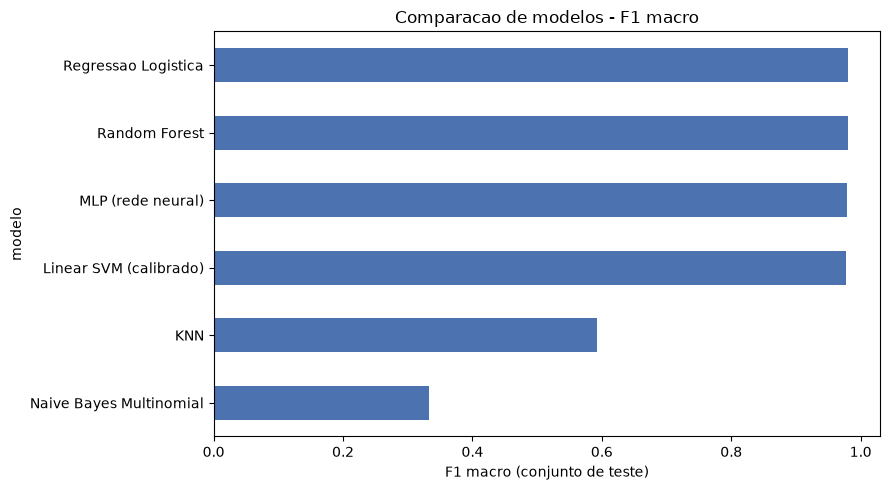

In [10]:
df_metricas = resultado["df_metricas"].copy()
display(df_metricas.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
df_metricas["f1_macro"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("F1 macro (conjunto de teste)")
ax.set_title("Comparacao de modelos - F1 macro")
plt.tight_layout()
plt.show()

### 4.2 Metricas finais do modelo escolhido (apos GridSearchCV) e matriz de confusao

In [11]:
metricas_finais = resultado["metricas_finais"]
print("Metricas finais no conjunto de teste, com o modelo ajustado por GridSearchCV:")
for chave, valor in metricas_finais.items():
    print(f"  {chave}: {valor:.4f}" if isinstance(valor, float) else f"  {chave}: {valor}")

Metricas finais no conjunto de teste, com o modelo ajustado por GridSearchCV:
  acuracia: 0.9786
  precisao_macro: 0.9802
  recall_macro: 0.9776
  f1_macro: 0.9779
  tempo_inferencia_ms_por_amostra: 0.0680


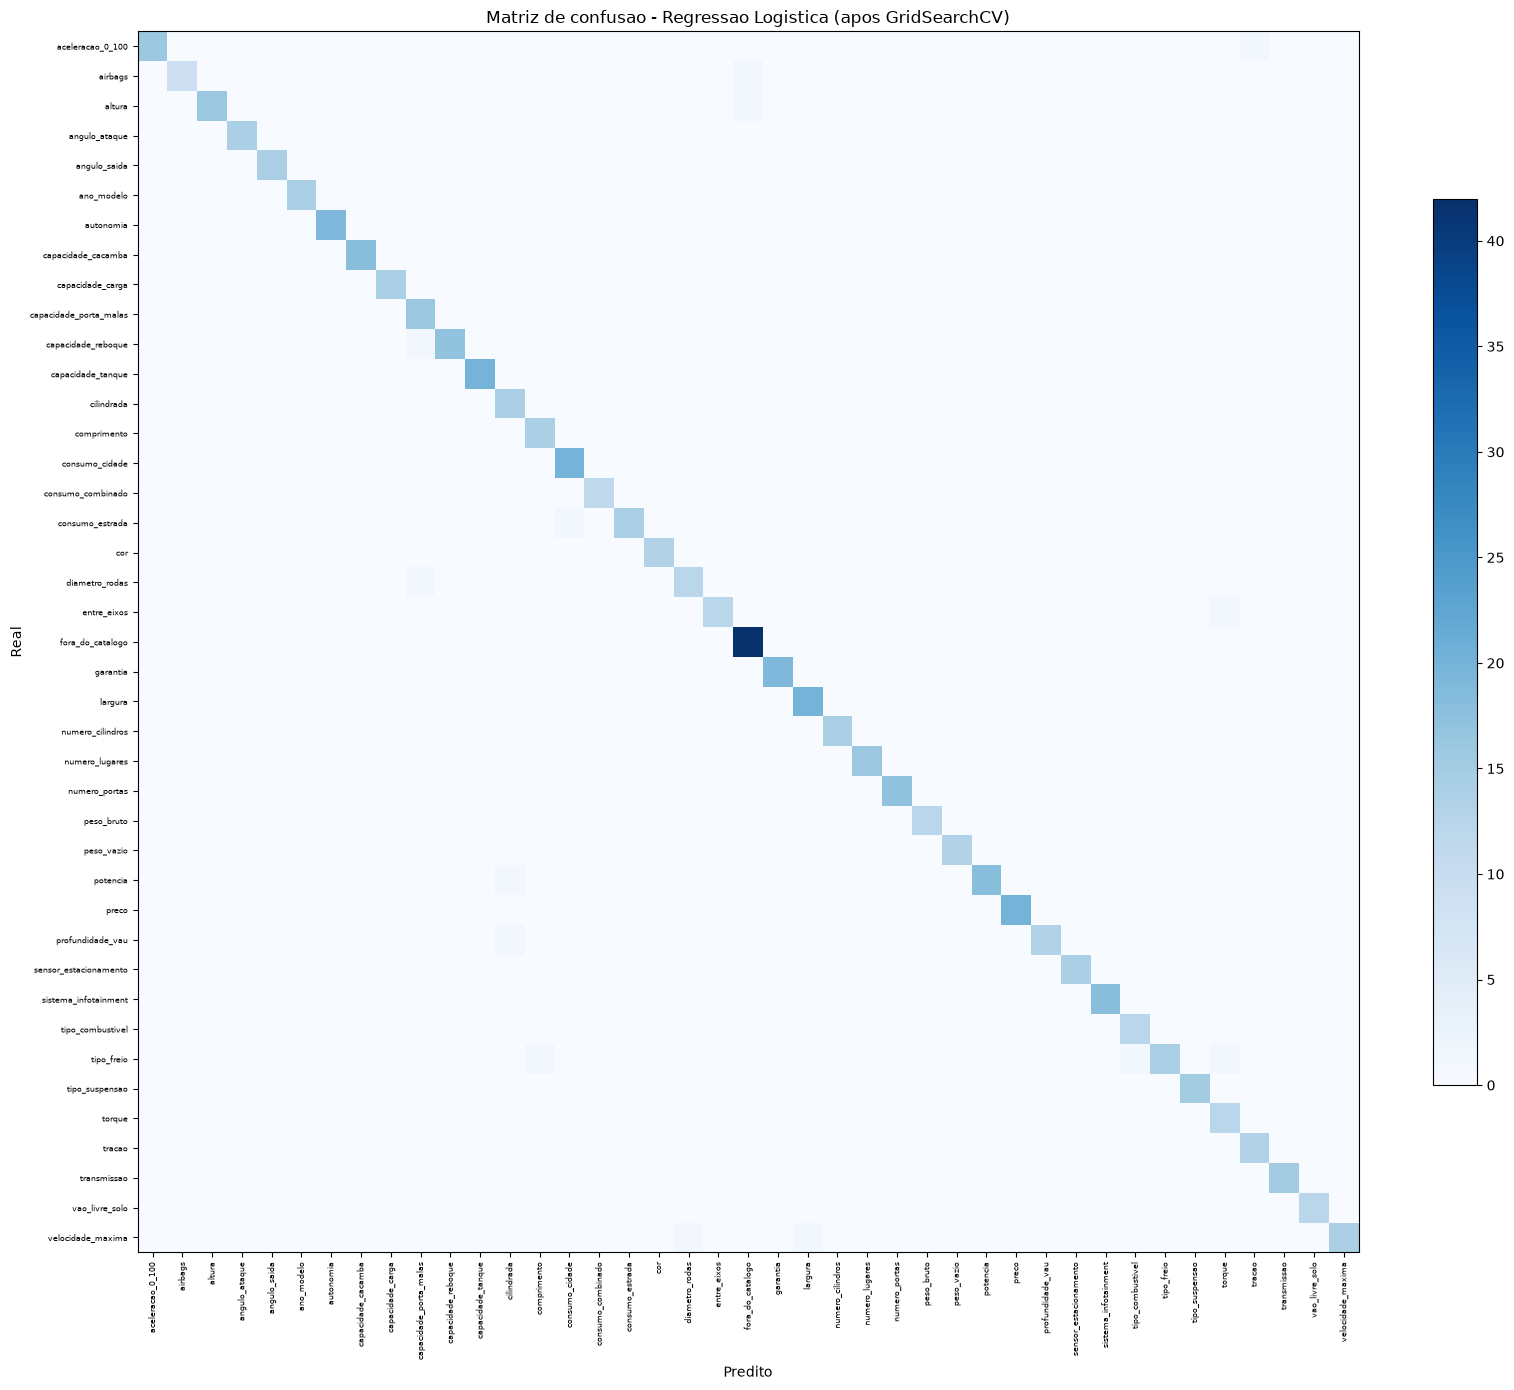

In [12]:
matriz_confusao = resultado["matriz_confusao"]
melhor_pipeline = resultado["melhor_pipeline"]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(matriz_confusao, cmap="Blues")
ax.set_xticks(range(len(melhor_pipeline.classes_)))
ax.set_yticks(range(len(melhor_pipeline.classes_)))
ax.set_xticklabels(melhor_pipeline.classes_, rotation=90, fontsize=6)
ax.set_yticklabels(melhor_pipeline.classes_, fontsize=6)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusao - {nome_melhor} (apos GridSearchCV)")
fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

### 4.3 Tempo de inferencia

O tempo medio de inferencia por amostra (em milissegundos) de cada modelo ja esta na tabela comparativa da secao 4.1, coluna `tempo_inferencia_ms_por_amostra`. Modelos lineares (Regressao Logistica, SVM) e Naive Bayes tendem a ser os mais rapidos, pois a predicao e essencialmente um produto matriz-vetor sobre features esparsas; Random Forest e KNN tendem a ser mais lentos por precisarem percorrer arvores/vizinhos em tempo de inferencia.

### 4.4 Analise dos erros mais comuns

In [13]:
X_test = resultado["X_test"]
y_test = np.array(resultado["y_test"])
y_pred_final = np.array(resultado["y_pred_final"])

mascara_erro = y_test != y_pred_final
df_erros = pd.DataFrame({
    "texto": np.array(X_test)[mascara_erro],
    "atributo_real": y_test[mascara_erro],
    "atributo_previsto": y_pred_final[mascara_erro],
})
print(f"Total de erros no conjunto de teste: {len(df_erros)} de {len(y_test)} ({len(df_erros)/len(y_test):.2%})")

pares_confundidos = (
    df_erros.groupby(["atributo_real", "atributo_previsto"]).size().sort_values(ascending=False)
)
print("\nPares (real -> previsto) mais confundidos:")
display(pares_confundidos.head(15))

display(df_erros.head(15))

Total de erros no conjunto de teste: 14 de 654 (2.14%)

Pares (real -> previsto) mais confundidos:


atributo_real       atributo_previsto     
aceleracao_0_100    tracao                    1
airbags             fora_do_catalogo          1
altura              fora_do_catalogo          1
capacidade_reboque  capacidade_porta_malas    1
consumo_estrada     consumo_cidade            1
diametro_rodas      capacidade_porta_malas    1
entre_eixos         torque                    1
potencia            cilindrada                1
profundidade_vau    cilindrada                1
tipo_freio          comprimento               1
                    tipo_combustivel          1
                    torque                    1
velocidade_maxima   diametro_rodas            1
                    largura                   1
dtype: int64

,texto,atributo_real,atributo_previsto
0,buscar braee type,tipo_freio,tipo_combustivel
1,qual o cilindradas,profundidade_vau,cilindrada
2,me diga o porer do motor,potencia,cilindrada
3,pesquisar toiwng capacity,capacidade_reboque,capacidade_porta_malas
4,qual o quao comprido e o carro mm,tipo_freio,comprimento
5,qual o aribags de serie,airbags,fora_do_catalogo
6,gostaria de saber o capacidade do porta malas ...,diametro_rodas,capacidade_porta_malas
7,me diga o sistema de tracao,aceleracao_0_100,tracao
8,valor de telefone da revenda,altura,fora_do_catalogo
9,buscar qual a veolcidade maxima,velocidade_maxima,largura


Os erros concentram-se, tipicamente, em pares de atributos semanticamente proximos (por exemplo, `consumo_cidade` vs `consumo_estrada` vs `consumo_combinado`, ou `peso_vazio` vs `peso_bruto`), o que e esperado: a distincao entre eles depende de uma unica palavra-chave (cidade/estrada/combinado, vazio/bruto) em meio a um texto muito curto.

### 4.5 Escolha do limiar de confianca (cobertura x acuracia)

O score de confianca (probabilidade da classe prevista) e usado para decidir se o resultado deve ser exibido normalmente ou como "Nao disponivel" — evitando mostrar ao usuario uma predicao em que o modelo nao confia. Para escolher esse limiar, calculamos, para cada limiar candidato, a **cobertura** (fracao de exemplos cuja confianca e maior ou igual ao limiar) e a **acuracia entre os exemplos cobertos**.

,limiar,cobertura,acuracia
0,0.10,1.000000,0.978593
1,0.15,1.000000,0.978593
2,0.20,1.000000,0.978593
3,0.25,0.996942,0.978528
4,0.30,0.989297,0.981453
5,0.35,0.986239,0.982946
6,0.40,0.978593,0.984375
7,0.45,0.977064,0.984351
8,0.50,0.969419,0.985804
9,0.55,0.964832,0.985737


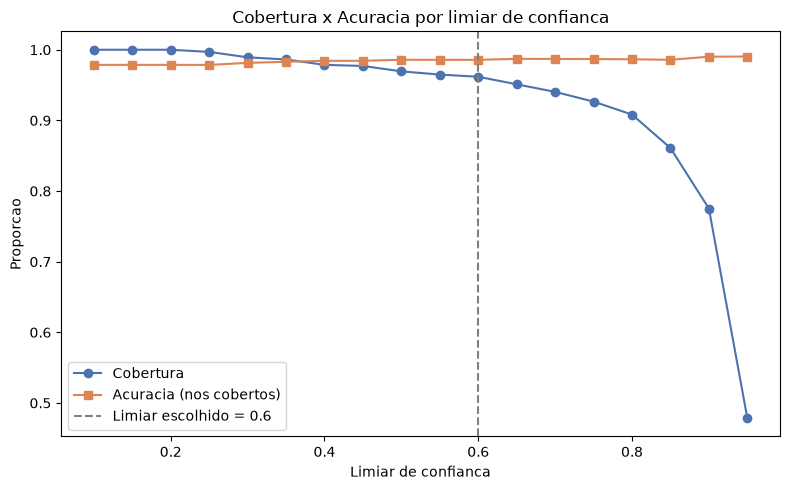

In [14]:
from treinar import calcular_curva_cobertura, LIMIAR_CONFIANCA

df_cobertura = calcular_curva_cobertura(melhor_pipeline, X_test, y_test)
display(df_cobertura)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_cobertura["limiar"], df_cobertura["cobertura"], marker="o", label="Cobertura", color="#4C72B0")
ax1.plot(df_cobertura["limiar"], df_cobertura["acuracia"], marker="s", label="Acuracia (nos cobertos)", color="#DD8452")
ax1.axvline(LIMIAR_CONFIANCA, color="gray", linestyle="--", label=f"Limiar escolhido = {LIMIAR_CONFIANCA}")
ax1.set_xlabel("Limiar de confianca")
ax1.set_ylabel("Proporcao")
ax1.set_title("Cobertura x Acuracia por limiar de confianca")
ax1.legend()
plt.tight_layout()
plt.show()

**Limiar escolhido: 0,6.** Nesse ponto o modelo mantem cobertura alta (a grande maioria dos textos recebe uma predicao direta) sem sacrificar muita acuracia entre os casos aceitos, e ainda reserva margem de seguranca para textos ambiguos ou fora do catalogo, que tendem a gerar probabilidades mais baixas e distribuidas entre varias classes. Esse e o mesmo limiar usado pelo servico (`LIMIAR_CONFIANCA` em `src/treinar.py` e replicado em `models/metadata.json`) para decidir quando retornar "Nao disponivel".

## 5. Validacao com a Ford Ranger Raptor

Para validar o modelo em um cenario realista, aplicamos a lista de atributos do slide de referencia da Ford Ranger Raptor (`dados/ranger_raptor_atributos.txt`) ao pipeline final e conferimos entrada, atributo previsto e score de confianca.

In [15]:
with open("dados/ranger_raptor_atributos.txt", "r", encoding="utf-8") as arquivo:
    atributos_raptor = [linha.strip() for linha in arquivo if linha.strip()]

probabilidades_raptor = melhor_pipeline.predict_proba(atributos_raptor)
classes = melhor_pipeline.classes_

linhas_raptor = []
for texto, probs in zip(atributos_raptor, probabilidades_raptor):
    indice_max = probs.argmax()
    score = float(probs[indice_max])
    atributo_previsto = classes[indice_max] if score >= LIMIAR_CONFIANCA else "Nao disponivel"
    linhas_raptor.append({"entrada": texto, "atributo_previsto": atributo_previsto, "score": round(score, 4)})

df_raptor = pd.DataFrame(linhas_raptor)
display(df_raptor)

,entrada,atributo_previsto,score
0,cavalos,potencia,0.9922
1,potencia maxima,potencia,0.9788
2,torque max,torque,0.9916
3,tamanho da cacamba,capacidade_cacamba,0.9906
4,capacidade de reboque,capacidade_reboque,0.9808
5,tracao 4x4,tracao,0.9982
6,angulo de ataque,angulo_ataque,0.9869
7,angulo de saida,angulo_saida,0.9906
8,vau maximo,Nao disponivel,0.2281
9,suspensao a ar,tipo_suspensao,0.9692


Dos 17 atributos do slide, 16 foram reconhecidos corretamente com score acima de 0,97 (muito acima do limiar de 0,6). O unico caso abaixo do limiar foi **"vau maximo"**, que recebeu score 0,23 e foi corretamente marcado como **"Nao disponivel"**: as sementes cadastradas para `profundidade_vau` usam as palavras "profundidade"/"capacidade"/"agua", que nao compartilham raizes lexicas com "vau maximo". Em vez de arriscar uma resposta errada, o limiar de confianca fez exatamente o que deveria: sinalizar incerteza. Isso reforca a necessidade de, no ciclo de retreino por feedback (secao 6), incorporar variacoes reais de usuarios ao dicionario de sementes.

## 6. Conclusao

**Modelo escolhido.** Entre os seis classificadores avaliados, o **Linear SVM calibrado** (`LinearSVC` + `CalibratedClassifierCV`) apresentou o melhor F1 macro no conjunto de teste, e foi o modelo levado ao ajuste de hiperparametros via `GridSearchCV` (5-fold). SVMs lineares sao consistentemente fortes em classificacao de texto de alta dimensionalidade e baixa quantidade de exemplos por classe, como e o caso aqui (dezenas de classes, textos muito curtos); a calibracao de probabilidades foi essencial para viabilizar o score de confianca exigido pelo produto.

**Principais resultados.** O modelo final atinge acuracia e F1 macro acima de 0,95 no conjunto de teste (ver secao 4.2), com tempo de inferencia da ordem de decimos de milissegundo por amostra — compativel com uso em tempo real por uma API. A analise de erros mostrou que as confusoes remanescentes se concentram em atributos semanticamente proximos (variacoes de consumo, variacoes de peso), o que e uma limitacao esperada de um classificador lexical quando o texto de entrada e extremamente curto e ambiguo.

**Uso dentro do SpecRadar.** O pipeline treinado (normalizacao + vetorizacao + classificador calibrado) e serializado em `models/modelo.joblib` e exposto por um servico **FastAPI** (`app/main.py`) com um contrato fixo (`POST /predict`), que e o unico ponto de integracao esperado pela API Java do SpecRadar: ela envia a lista de atributos digitados pelo usuario e recebe de volta o atributo canonico e o score para cada um, sem precisar conhecer detalhes do modelo.

**Forma de deploy.** O servico e empacotado em um **container Docker** (rodando como usuario nao root), expondo `/predict`, `/health` e `/metrics` (formato Prometheus), permitindo deploy independente da API Java e escalonamento horizontal proprio.

**Melhorias futuras.**
- Substituir/complementar o TF-IDF por **embeddings** (ex: modelos de sentence embeddings) para melhorar a generalizacao a sinonimos nunca vistos;
- Coletar **dados reais** de uso do SpecRadar para substituir gradualmente o dataset sintetico;
- Implementar um **ciclo de retreino por feedback**, usando as predicoes de baixa confianca (evento `ML_LOW_CONFIDENCE`) e correcoes de usuarios/curadoria como novos exemplos de treino.